# Temporal-axis data-efficiency — rollout variant (Norway probes, EU 14y)

Folders: `snapshot_14y_eu_temporal_rollout_norway_lat16_mtpi` (no-TESSERA baseline +
ERA5-interp arms, schedule) and `snapshot_14y_eu_temporal_rollout_norway_tessera_1B-M_2017`
(TESSERA arm). Source of the paper's simulated-Norway-deployment figure (preprint Fig 7,
AMS Fig 9); `scripts/paper/make_paper_figures.py fig07` re-renders it.

Two mechanisms are combined per sweep point to simulate a **strict snapshot at
wall-clock time T**:

1. **Staggered per-station `probe_active_from`** — probe stations come online linearly
   between `T_0` (rollout anchor) and `T_0 + T_rollout`. The activation order is a
   fixed permutation (`activation_order_seed=0`); each station's per-sweep `active_from`
   is either its individual activation timestamp (if it has been deployed by the
   snapshot time) or the future-sentinel `9999-12-31-23` (if it hasn't).
2. **Uniform `train_end_override`** — the train/val boundary is shifted earlier to
   `T_0 + x` for that sweep. Training observations after this timestamp are excluded
   for **every** station — probes AND always-on. ERA5 normalisation stats are
   intentionally computed from the *full* metadata train_end window, NOT the override,
   so cross-sweep z-score scales are preserved (otherwise the curves would conflate
   model performance with normalisation drift).

The actual schedule (`T_0`, `T_rollout`, per-station activation timestamps, per-sweep
`train_end_override` values) is materialised in
`scripts/experiments/snapshot_14y_eu_temporal_rollout_norway_lat16_mtpi/rollout_schedule.json` and
read by `submit.sh` to produce the per-sweep JSON sidecars.

## X-axis: elapsed wall-clock time since rollout started

Swept over `{r1mo, r3mo, r6mo, r1y, r2y, r3y, r6y}`. **Unlike** the uniform-horizon
notebook, the x-axis here is *not* per-probe-station history depth — it's the
calendar time elapsed since `T_0`. The relationship between elapsed time and the
amount of data per station depends on (a) which probe stations are online yet
(staggered) and (b) the train_end_override.

## Subset metrics

`always_on` / `probe` / `spatial_test` are emitted by `evaluate.py` exactly as in
the uniform-horizon notebook. **Crucially**, the expected shapes differ:

* **`always_on`** — NOT flat in x here. As x decreases, `train_end_override` shrinks
  the training window for every station (not just the probes), so the always-on
  curve should degrade with smaller x. This is the intended behaviour: the snapshot
  simulation reflects that early in a rollout, *every* station has less history.
* **`probe`** — the headline curve, with extra structure: at small x, few probes
  are online and those that are online have tiny histories; at large x (≥ r3y),
  all probes are online and each has accumulated several years of data.
* **`spatial_test`** — held-out stations. Expected to track `always_on` in shape
  (both subject to the same `train_end_override`), with the spatial-generalisation
  gap on top.


In [36]:
import sys
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import _helpers
import importlib
importlib.reload(_helpers)

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.constrained_layout.use': True,
})

# FOLDER = 'snapshot_14y_eu_temporal_rollout_alps'
# FOLDER = 'snapshot_14y_eu_temporal_rollout_norway'              # legacy: lat16->proj8, Gaussian wind
FOLDER = 'snapshot_14y_eu_temporal_rollout_norway_lat16_mtpi'     # lat16-DIRECT + mTPI; wind=trunc-normal, t2m=Gaussian

# --- TESSERA latents generation (pick ONE) ----------------------------------
# The TESSERA arm was retrained per latents generation with identical design +
# schedule (the rollout artifacts are byte-identical copies) — only the
# latents file differs. The no-TESSERA baseline + ERA5-interp rows are
# latents-independent and always come from FOLDER. Run stems are identical
# across generations, so everything downstream follows this choice.
#
# Current main: TESSERA v2 "1B-M", 2017 embeddings (crop64_lat16_auxon).
TESSERA_FOLDER = 'snapshot_14y_eu_temporal_rollout_norway_tessera_1B-M_2017'
# Previous main: TESSERA v1 16-d latents (arm lives in FOLDER itself).
# TESSERA_FOLDER = FOLDER

SEEDS = [42, 123, 456]
VARIABLES = ['t2m', 'wind']
SUBSETS = ['always_on', 'probe', 'spatial_test']

# Sweep label → elapsed years since rollout started. Matches the
# `elapsed_months` field in rollout_schedule.json's per-sweep entries.
# The post-completion regime (r3y..r6y) is now sampled yearly (r3y, r4y,
# r5y, r6y) instead of a single 3-year jump, so the maturation shape is
# resolved rather than linearly interpolated.
SWEEP_X_YEARS = {
    'r0':   0.0,
    'r1mo': 1 / 12,
    'r3mo': 0.25,
    'r6mo': 0.50,
    'r1y':  1.0,
    'r2y':  2.0,
    'r3y':  3.0,
    'r4y':  4.0,
    'r5y':  5.0,
    'r6y':  6.0,
}
SWEEP_ORDER = ['r0', 'r1mo', 'r3mo', 'r6mo', 'r1y', 'r2y', 'r3y', 'r4y', 'r5y', 'r6y']

# Architecture config names → family. These mirror snapshot_14y_eu's
# canonical mTPI variants: TESSERA latents concatenated DIRECTLY at 16-d
# (no proj-dim head) + per-station mTPI; the no-TESSERA baseline keeps its
# ERA5 static fields and also gains mTPI. Wind uses a TRUNCATED-NORMAL head
# (so wind point metrics are reported on the predictive median — only the
# top-level `wind_mae` is renamed `wind_mae_at_median`; the per-subset
# `wind_{subset}_mae` keys the curves use are unchanged). t2m stays Gaussian.
FAMILY_OF = {
    't2m_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd':              'tessera',
    't2m_snap_bilinear_baseline_mtpi_wd':                                'baseline',
    't2m_snap_era5_interp_baseline':                                     'era5_interp',
    't2m_snap_era5_interp_lapse_baseline':                               'era5_interp',
    'wind_truncnormal_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd': 'tessera',
    'wind_truncnormal_snap_bilinear_baseline_mtpi_wd':                   'baseline',
    'wind_snap_era5_interp_baseline':                                    'era5_interp',
}

# Which ERA5-interpolation run supplies the dashed reference line, per
# variable. t2m uses the LAPSE-RATE-CORRECTED interpolation: ERA5's 2 m
# temperature is valid at the model orography, which in Norway sits far
# from the true station height, so the uncorrected field carries an
# elevation bias that has nothing to do with downscaling skill. The
# correction is T_station = T_interp - G * delta_elev at the textbook
# G = 6.5 K/km, using only delta_elev — a feature the ConvCNPs already
# receive, so the reference gains no information the models lack. It is a
# markedly stronger reference than plain interp (1.350 vs 1.552 MAE over
# the European test set). Wind has no lapse analogue, so it stays plain.
# The rollout figures do NOT draw these global numbers: they re-aggregate
# the interpolant over each panel's own stations at each x (see
# _era_col_metric), so the reference answers "what does ERA5 get on
# exactly these stations" rather than "what does ERA5 get on Europe".
ERA_REF_ARCH = {'t2m': 't2m_snap_era5_interp_lapse_baseline',
                'wind': 'wind_snap_era5_interp_baseline'}

# Family is encoded by COLOUR + MARKER (consistent across all panels);
# both families use a SOLID line. In the spatial_test panel the line style
# is repurposed to distinguish region (Norway solid / non-Norway dotted),
# so colour+marker still read as family there too.
FAMILY_COLOUR    = {'tessera': '#1f77b4', 'baseline': '#7f7f7f'}
FAMILY_LINESTYLE = {'tessera': '-',       'baseline': '-'}
FAMILY_MARKER    = {'tessera': 'o',       'baseline': 's'}

# Families every rollout figure iterates over (order = legend order).
FAMILIES = ['tessera', 'baseline']


In [37]:
# Print the rollout schedule's headline metadata, so the notebook is
# self-describing. The actual per-station activation timestamps live in
# rollout_schedule.json's `sweep_points[*].probe_active_from` block and
# can be inspected via the file directly if needed.
schedule_path = _helpers.experiments_dir() / FOLDER / 'rollout_schedule.json'
if schedule_path.exists():
    schedule = json.loads(schedule_path.read_text())
    meta = schedule['schedule_metadata']
    print(f'Rollout schedule (from {schedule_path.name}):')
    print(f'  T_0                     = {meta["rollout_anchor_t_0"]}')
    print(f'  rollout completion      = {meta["rollout_completion_t"]}')
    print(f'  T_rollout (months)      = {meta["t_rollout_months"]}')
    print(f'  cadence shape           = {meta["cadence_shape"]}')
    print(f'  activation order seed   = {meta["activation_order_seed"]}')
    print(f'  n probe stations        = {meta["n_stations"]}')
    print(f'  dataset train_start     = {meta["dataset_train_start"]}')
    print(f'  dataset train_end       = {meta["dataset_train_end"]}')
    print()
    print('  Per-sweep snapshot times + fraction of probes online:')
    for label in SWEEP_ORDER:
        sp = schedule['sweep_points'][label]
        n_online = sum(
            1 for v in sp['probe_active_from'].values() if not v.startswith('9999')
        )
        n_total = len(sp['probe_active_from'])
        print(
            f'    {label:5s}  '
            f'train_end_override = {sp["train_end_override"]}   '
            f'probes online = {n_online}/{n_total} '
            f'({100 * n_online / n_total:.1f} %)'
        )
else:
    print(f'(no rollout_schedule.json at {schedule_path})')


Rollout schedule (from rollout_schedule.json):
  T_0                     = 2014-12-31-23
  rollout completion      = 2017-12-31-23
  T_rollout (months)      = 36
  cadence shape           = linear
  activation order seed   = 0
  n probe stations        = 1505
  dataset train_start     = 2010-01-01-00
  dataset train_end       = 2020-12-31

  Per-sweep snapshot times + fraction of probes online:
    r0     train_end_override = 2014-12-31-23   probes online = 0/1505 (0.0 %)
    r1mo   train_end_override = 2015-01-31-23   probes online = 43/1505 (2.9 %)
    r3mo   train_end_override = 2015-03-31-23   probes online = 124/1505 (8.2 %)
    r6mo   train_end_override = 2015-06-30-23   probes online = 249/1505 (16.5 %)
    r1y    train_end_override = 2015-12-31-23   probes online = 502/1505 (33.4 %)
    r2y    train_end_override = 2016-12-31-23   probes online = 1004/1505 (66.7 %)
    r3y    train_end_override = 2017-12-31-23   probes online = 1505/1505 (100.0 %)
    r4y    train_end_override =

In [38]:
df = _helpers.load_folder_results(FOLDER, seeds=SEEDS)
if TESSERA_FOLDER != FOLDER:
    df = pd.concat([df, _helpers.load_folder_results(TESSERA_FOLDER, seeds=SEEDS)],
                   ignore_index=True)
print(f'Loaded {len(df)} run records.')
if not df.empty:
    print(f'Experiments: {df["experiment"].nunique()}')
    counts = df.groupby('experiment').size().sort_index()
    print('\nRun counts per experiment (expected 3 = one per seed):')
    print(counts.to_string())


Loaded 183 run records.
Experiments: 43

Run counts per experiment (expected 3 = one per seed):
experiment
t2m_snap_bilinear_baseline_mtpi_wd_r0                                      3
t2m_snap_bilinear_baseline_mtpi_wd_r1mo                                    3
t2m_snap_bilinear_baseline_mtpi_wd_r1y                                     3
t2m_snap_bilinear_baseline_mtpi_wd_r2y                                     3
t2m_snap_bilinear_baseline_mtpi_wd_r3mo                                    3
t2m_snap_bilinear_baseline_mtpi_wd_r3y                                     3
t2m_snap_bilinear_baseline_mtpi_wd_r4y                                     3
t2m_snap_bilinear_baseline_mtpi_wd_r5y                                     3
t2m_snap_bilinear_baseline_mtpi_wd_r6mo                                    3
t2m_snap_bilinear_baseline_mtpi_wd_r6y                                     3
t2m_snap_era5_interp_baseline                                              1
t2m_snap_era5_interp_lapse_baseline           

In [39]:
def _split_experiment(name: str) -> tuple[str, str]:
    for label in SWEEP_ORDER:
        suffix = f'_{label}'
        if name.endswith(suffix):
            return name[:-len(suffix)], label
    # Simple baseline (no sweep cross-product): land in 'all'.
    return name, 'all'

if not df.empty:
    parsed = df['experiment'].apply(_split_experiment)
    df['arch_base']   = parsed.apply(lambda t: t[0])
    df['sweep_label'] = parsed.apply(lambda t: t[1])
    df['x_years']     = df['sweep_label'].map(SWEEP_X_YEARS)
    df['family']      = df['arch_base'].map(FAMILY_OF).fillna('unknown')
    if TESSERA_FOLDER != FOLDER:
        # TESSERA arm exclusively from TESSERA_FOLDER; baseline + ERA5-interp
        # exclusively from FOLDER (stems are identical across generations).
        df = df[((df['source_folder'] == FOLDER) & (df['family'] != 'tessera'))
                | ((df['source_folder'] == TESSERA_FOLDER) & (df['family'] == 'tessera'))].copy()
    df['variable']    = df['arch_base'].apply(
        lambda s: 't2m' if s.startswith('t2m_')
        else 'wind' if s.startswith('wind_')
        else 'unknown'
    )
    print(
        df[['arch_base', 'family', 'variable', 'sweep_label', 'x_years']]
          .drop_duplicates()
          .sort_values(['variable', 'family', 'x_years'])
          .to_string(index=False)
    )


                                                         arch_base      family variable sweep_label  x_years
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m          r0 0.000000
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m        r1mo 0.083333
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m        r3mo 0.250000
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m        r6mo 0.500000
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m         r1y 1.000000
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m         r2y 2.000000
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m         r3y 3.000000
                                t2m_snap_bilinear_baseline_mtpi_wd    baseline      t2m         r4y 4.000000
                   

In [40]:
# ----------------------------------------------------------------------
# Held-out (spatial_test) curve, split by region: Norway vs non-Norway.
#
# evaluate.py emits a single `spatial_test` subset that pools ALL held-out
# Europe stations (region_specs_test = {europe: all}); only ~14% of them
# lie in Norway. Because the rollout deploys *Norwegian* probe stations,
# whatever held-out gain it produces is concentrated in the Norwegian
# held-out stations, while the non-Norwegian majority stays ~flat. To make
# that explicit we re-derive the held-out curve split by region from the
# per-station error files (test_station_errors.npz), classifying a held-out
# station as Norwegian iff it falls in the SAME bbox that defines the probe
# set (so "Norwegian" means the same thing on the train and test sides).
#
# Metric matches the grid's aggregate exactly: micro (observation-weighted)
# MAE, so the count-weighted recombination of the two regional curves
# reproduces `{var}_spatial_test_mae` to machine precision (checked below).
# ----------------------------------------------------------------------
_probe_meta = json.loads(
    (_helpers.experiments_dir() / FOLDER / 'probe_station_ids.json').read_text()
)
HELDOUT_BBOX_LAT = tuple(_probe_meta['bbox_lat'])   # Norway: (58.0, 71.0)
HELDOUT_BBOX_LON = tuple(_probe_meta['bbox_lon'])   # Norway: (4.0, 31.0)


def _heldout_split_for_run(run_dir: str, variable: str) -> dict | None:
    """Micro-MAE of the held-out subset split into Norway / non-Norway.

    Returns None if the run has no per-station file or no predictions for
    this variable (e.g. a t2m run carries no wind errors).
    """
    npz_path = Path(run_dir) / 'test_station_errors.npz'
    if not npz_path.exists():
        return None
    d = np.load(npz_path, allow_pickle=True)
    if f'{variable}_station_mae' not in d.files:
        return None
    keep = (d['subset_per_station'] == 'spatial_test') & (
        d[f'{variable}_station_count'] > 0
    )
    lat = d['station_lats'][keep]
    lon = d['station_lons'][keep]
    mae = d[f'{variable}_station_mae'][keep].astype(float)
    cnt = d[f'{variable}_station_count'][keep].astype(float)
    in_norway = (
        (lat >= HELDOUT_BBOX_LAT[0]) & (lat <= HELDOUT_BBOX_LAT[1])
        & (lon >= HELDOUT_BBOX_LON[0]) & (lon <= HELDOUT_BBOX_LON[1])
    )

    def _micro(sel):
        return (float((mae[sel] * cnt[sel]).sum() / cnt[sel].sum())
                if sel.any() else np.nan)

    return {
        'norway':    _micro(in_norway),
        'other':     _micro(~in_norway),
        'n_norway':  int(in_norway.sum()),
        'n_other':   int((~in_norway).sum()),
        'w_norway':  float(cnt[in_norway].sum()),
        'w_other':   float(cnt[~in_norway].sum()),
        'agg_micro': float((mae * cnt).sum() / cnt.sum()),
    }


if df.empty:
    df_held = pd.DataFrame()
    print('(no data — skipping held-out split)')
else:
    _split_records = []
    for _, _row in df[df['family'].isin(FAMILIES)].iterrows():
        _s = _heldout_split_for_run(_row['run_dir'], _row['variable'])
        if _s is None:
            continue
        for _region in ('norway', 'other'):
            _split_records.append({
                'variable':    _row['variable'],
                'family':      _row['family'],
                'sweep_label': _row['sweep_label'],
                'x_years':     _row['x_years'],
                'seed':        _row['seed'],
                'region':      _region,
                'mae':         _s[_region],
                'n_stations':  _s[f'n_{_region}'],
                'weight':      _s[f'w_{_region}'],
                'agg_micro':   _s['agg_micro'],
            })
    df_held = pd.DataFrame(_split_records)

    # Sanity: count-weighted recombination must reproduce the aggregate
    # spatial_test micro-MAE that the grid plots (machine-precision check).
    _seed_mean = (df_held
                  .groupby(['variable', 'family', 'sweep_label', 'region'])
                  .agg(mae=('mae', 'mean'), weight=('weight', 'mean'),
                       agg_micro=('agg_micro', 'mean'))
                  .reset_index())
    _nor = _seed_mean[_seed_mean['region'] == 'norway'].set_index(
        ['variable', 'family', 'sweep_label'])
    _oth = _seed_mean[_seed_mean['region'] == 'other'].set_index(
        ['variable', 'family', 'sweep_label'])
    _recomb = ((_nor['mae'] * _nor['weight'] + _oth['mae'] * _oth['weight'])
               / (_nor['weight'] + _oth['weight']))
    _max_err = float((_recomb - _nor['agg_micro']).abs().max())

    _counts = (df_held.groupby(['variable', 'region'])['n_stations']
               .first().unstack())
    print('Held-out split built (micro-MAE, observation-weighted).')
    print('Held-out station counts by variable:')
    print(_counts.to_string())
    print(f'\nRecombination vs aggregate spatial_test MAE: '
          f'max abs err = {_max_err:.1e}  (should be ~0)')

    # Deltas over the rollout, per region — the headline of this split.
    print('\nMicro-MAE change r1mo -> r6y (held-out subset):')
    for _variable in VARIABLES:
        for _family in FAMILIES:
            _sl = (df_held[(df_held['variable'] == _variable)
                           & (df_held['family'] == _family)]
                   .groupby(['region', 'sweep_label'])['mae'].mean())
            if ('norway', 'r6y') not in _sl or ('norway', 'r1mo') not in _sl:
                continue
            _dn = _sl[('norway', 'r6y')] - _sl[('norway', 'r1mo')]
            _do = _sl[('other', 'r6y')] - _sl[('other', 'r1mo')]
            print(f'  {_variable:4s} {_family:8s}  '
                  f'Norway Δ={_dn:+.3f}   non-Norway Δ={_do:+.3f}')


Held-out split built (micro-MAE, observation-weighted).
Held-out station counts by variable:
region    norway  other
variable               
t2m          130    768
wind          95    455

Recombination vs aggregate spatial_test MAE: max abs err = 2.2e-16  (should be ~0)

Micro-MAE change r1mo -> r6y (held-out subset):
  t2m  tessera   Norway Δ=-0.297   non-Norway Δ=-0.045
  t2m  baseline  Norway Δ=-0.113   non-Norway Δ=-0.027
  wind tessera   Norway Δ=-0.105   non-Norway Δ=-0.027
  wind baseline  Norway Δ=-0.242   non-Norway Δ=-0.047


In [41]:
# ----------------------------------------------------------------------
# Shared machinery for the 3-column rollout figures (reconstructed after
# the original MAE 3-column cell was deleted). Everything here is reused
# by the figure cells below (always-held-out figure, RMSE/CRPS variants
# and the placement analysis): the deployment schedule, the per-station
# metric arrays (mae/rmse/crps, with CRPS computed + cached per run from
# the saved distribution params), the micro-aggregation rule, seed
# aggregation, styling, and the manual top-axis helper.
# ----------------------------------------------------------------------
_sched = json.loads(
    (_helpers.experiments_dir() / FOLDER / 'rollout_schedule.json').read_text()
)

# Sweep label -> # probe stations deployed (online) at that snapshot.
# For this schedule: r1mo=43, r1y=502, r2y=1004, r3y..r6y=1505.
_dep_of = {
    label: sum(
        1 for v in _sched['sweep_points'][label]['probe_active_from'].values()
        if not str(v).startswith('9999')
    )
    for label in SWEEP_ORDER
}

# Column partition of the original 3-column figure (training-membership
# split of the Norwegian stations + the non-Norway held-out control).
COL_SPEC = [
    ('probe_deployed', 'Norway deployed stations (in training)'),
    ('norway_oot', 'Norway held-out stations\n(incl. pending deployment)'),
    ('heldout_nonnorway', 'Non-Norwegian held-out stations\n(control)'),
]

# Styling shared by every rollout figure.
_XLIM = (-0.2, 6.2)
VAR_LABEL = {'t2m': '2 m temperature', 'wind': '10 m wind speed'}
VAR_UNIT = {'t2m': '°C', 'wind': 'm/s'}
FAMILY_LABEL = {'tessera': 'ConvCNP with TESSERA',
                'baseline': 'ConvCNP (no TESSERA)'}

# ERA5-interp reference column per metric; the interpolant is deterministic,
# so its CRPS degenerates to its MAE.
_ERA_METRIC_COL = {'mae': '{v}_mae', 'rmse': '{v}_rmse', 'crps': '{v}_mae'}

_HEAD_CRPS_SEED = 0   # fixes the truncated-normal ensemble so caches are reproducible


def _station_crps(run_dir, variable):
    """Per-station mean CRPS (aligned with the station arrays), cached per run."""
    cache = Path(run_dir) / 'station_crps_cache.npz'
    key = f'{variable}_station_crps'
    if cache.exists():
        c = np.load(cache)
        if key in c.files:
            return c[key]
    import torch
    from tessera_downscaling.model.heads import GaussianHead, TruncatedNormalHead
    pr = np.load(Path(run_dir) / 'test_predictions.npz', allow_pickle=True)
    if f'{variable}_param_mu' not in pr.files:          # e.g. an ERA5-interp run
        return None
    mu = torch.tensor(np.asarray(pr[f'{variable}_param_mu'], dtype=np.float64))
    lv = torch.tensor(np.asarray(pr[f'{variable}_param_log_var'], dtype=np.float64))
    tg = torch.tensor(np.asarray(pr[f'{variable}_targets'], dtype=np.float64))
    sidx = np.asarray(pr[f'{variable}_station_indices'])
    torch.manual_seed(_HEAD_CRPS_SEED)
    head = object.__new__(GaussianHead if variable == 't2m' else TruncatedNormalHead)
    n_obs = mu.shape[0]
    crps = np.empty(n_obs)
    for i in range(0, n_obs, 500_000):                  # chunk to bound peak memory
        sl = slice(i, min(i + 500_000, n_obs))
        crps[sl] = head.crps({'mu': mu[sl], 'log_var': lv[sl]}, tg[sl]).numpy()
    n_st = len(np.load(Path(run_dir) / 'test_station_errors.npz',
                       allow_pickle=True)['station_ids'])
    ssum = np.bincount(sidx, weights=crps, minlength=n_st)
    scnt = np.bincount(sidx, minlength=n_st).astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        sval = np.where(scnt > 0, ssum / scnt, 0.0)
    payload = {}
    if cache.exists():
        cc = np.load(cache)
        payload = {k: cc[k] for k in cc.files}
    payload[key] = sval
    np.savez(cache, **payload)
    return sval


def _station_metric_arrays(run_dir, variable, metric):
    d = np.load(Path(run_dir) / 'test_station_errors.npz', allow_pickle=True)
    if f'{variable}_station_mae' not in d.files:
        return None
    ids = d['station_ids'].astype(str)
    lat, lon = d['station_lats'], d['station_lons']
    sub = d['subset_per_station']
    cnt = d[f'{variable}_station_count'].astype(float)
    if metric == 'mae':
        val = d[f'{variable}_station_mae'].astype(float)
    elif metric == 'rmse':
        val = d[f'{variable}_station_rmse'].astype(float)
    elif metric == 'crps':
        val = _station_crps(run_dir, variable)
        if val is None:
            return None
        val = val.astype(float)
    else:
        raise ValueError(metric)
    return ids, lat, lon, sub, cnt, val


def _micro_metric(val, cnt, sel, metric):
    if not sel.any():
        return np.nan
    if metric == 'rmse':                                # quadratic pooling, then sqrt
        return float(np.sqrt((val[sel] ** 2 * cnt[sel]).sum() / cnt[sel].sum()))
    return float((val[sel] * cnt[sel]).sum() / cnt[sel].sum())   # linear (mae / crps)


def _deployed_mask(ids, sweep_label):
    """Boolean mask (aligned with the station arrays) of the probes already
    deployed into training at this sweep, per the rollout schedule."""
    dep_ids = {
        sid for sid, v
        in _sched['sweep_points'][sweep_label]['probe_active_from'].items()
        if not str(v).startswith('9999')
    }
    return np.isin(ids.astype(str), list(dep_ids))


def _agg_seed(frame):
    """Seed aggregation for the figure cells: mean ± std per x position of
    the metric column (named 'mae' whichever metric it actually holds)."""
    return (frame.groupby('x_years')['mae'].agg(['mean', 'std'])
            .reset_index().sort_values('x_years').dropna(subset=['mean']))


def _add_top_axis(ax, xs, labels, fs=8, label_text=None):
    """Manually drawn secondary top axis: small ticks + horizontal labels
    at the given x positions (data coords) just above the axes, plus a
    centred axis label. y is in axes fraction so every panel keeps the same
    height (the panel titles use pad=45 to leave room)."""
    trans = ax.get_xaxis_transform()      # x = data coords, y = axes coords
    for x, lab in zip(xs, labels):
        ax.plot([x, x], [1.0, 1.025], transform=trans, color='black', lw=0.8,
                clip_on=False, zorder=5)
        ax.text(x, 1.045, str(lab), transform=trans, ha='center', va='bottom',
                fontsize=fs, clip_on=False)
    if label_text:
        ax.text(0.5, 1.135, label_text, transform=ax.transAxes, ha='center',
                va='bottom', fontsize=fs + 1)


print('Probes deployed per sweep:', _dep_of)

Probes deployed per sweep: {'r0': 0, 'r1mo': 43, 'r3mo': 124, 'r6mo': 249, 'r1y': 502, 'r2y': 1004, 'r3y': 1505, 'r4y': 1505, 'r5y': 1505, 'r6y': 1505}


Permanently held-out Norway stations per variable: {'t2m': 130, 'wind': 95}
Wrote /lus/lfs1aip2/projects/u6do/pmms2/end-to-end-forecasting/projects/tessera_downscaling/notebooks/norway_analysis_outputs/fig_norway_rollout_2col_alwaysheldout_rmse.png
Wrote /lus/lfs1aip2/projects/u6do/pmms2/end-to-end-forecasting/projects/tessera_downscaling/notebooks/norway_analysis_outputs/fig_norway_rollout_2col_alwaysheldout_rmse.pdf


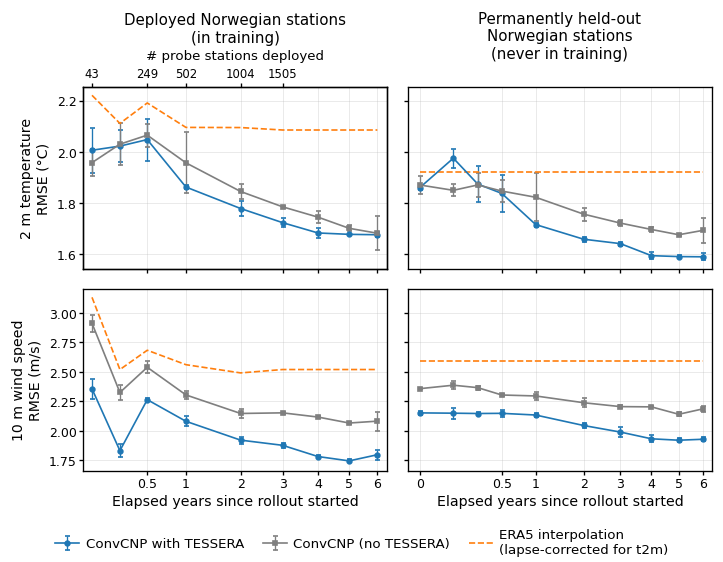

In [42]:
# ----------------------------------------------------------------------
# Paper figure — TRAINING-MEMBERSHIP partition of the Norwegian stations,
# two columns:
#   col 1  Norway deployed          — probes currently deployed into training
#   col 2  Norway held out (always) — the permanent held-out test stations
#                                     (spatial_test in the Norway bbox,
#                                     never in training at any snapshot)
# Col 2 isolates spillover: as more Norwegian probes are deployed, does
# performance improve on stations that never themselves enter training?
# Its station set is fixed at every snapshot, which is what makes the
# comparison across x a clean one.
#
# A third column used to sit between these two: not-yet-deployed probes
# UNION the permanent held-out set. It was cut because its station
# population shrinks along x (probes leave it as they deploy) and collapses
# onto col 2 at year 3, so curve, reference and station count all moved for
# two reasons at once. The not-yet-deployed probes are still worth
# reporting, so report_col('probe_undeployed') prints them — probes NOT yet
# in training, without the permanent held-out set mixed in — for quoting in
# prose.
#
# Col 1 carries the deployed-into-training count on the top axis (the
# shared x-driver); col 2 carries no count axis — see the note there.
#
# plot_ah_cols(metric) draws the figure for 'mae' | 'rmse' | 'crps'; the
# shared prefix cell supplies the per-station arrays (_station_metric_arrays,
# with CRPS computed + cached from the saved distribution params) and the
# micro-aggregation rule (_micro_metric). The ERA5-interp reference is drawn
# for point metrics only — CRPS is undefined for the deterministic bilinear
# interpolant. This cell draws RMSE; the cell below draws the MAE variant
# (the canonical paper filename).
#
# --- The ERA5 reference is PANEL-SPECIFIC ------------------------------
# It used to be one global constant (the run's top-level {v}_mae, pooled
# over every European test observation) repeated in all six panels, which
# compared the curves against ERA5's error on a different — and much
# easier, lowland-dominated — population than the Norwegian stations each
# panel actually scores. It is now re-aggregated over exactly the station
# set behind each point, with the same micro rule as the curves, so panel
# and reference answer the same question. Two consequences to read
# correctly:
#   * in cols 1-2 the reference is a CURVE, not a line. It moves because
#     the station population moves as probes deploy, not because a
#     deterministic interpolant improves. Col 3's set is fixed, so it is
#     flat there, and that is the panel where a curve/reference gap is
#     directly interpretable.
#   * the reference is restricted to stations the trained runs score, so
#     both sides are on one population (see _era_col_arrays).
#
# --- Figure geometry: drawn AT PRINT SIZE ------------------------------
# The figure is authored at the width it is included at (\textwidth, 1:1),
# so the point sizes below are the point sizes on the printed page — no
# LaTeX downscaling shrinking 11 pt text into 4 pt. That is what makes the
# panels sit close together: the horizontal gaps are what constrained
# layout needs for the shared-row y ticks, not the leftovers of an 18-inch
# canvas squeezed into 6.5 inches.
# Redundancy removed so the panels can be narrow:
#   * variable moved from the per-panel title into the row's y label, so
#     the column titles are set once on the top row;
#   * x label written once per column (bottom row only);
#   * the station-count top axis keeps its numbers on every panel, but the
#     label naming them is written once per column, on the top row;
#   * one figure-level legend under the panels instead of an in-panel one.
# _AH_FIGW is the width the figure is INCLUDED at — 5.85 in, i.e.
# \includegraphics[width=0.90\textwidth] of a 6.5 in text block — so the
# point sizes above are the point sizes on the page, at 1:1. Change
# _AH_FIGW if that include width changes. What is NOT fine is authoring
# wide and shrinking hard: that is how the 18-inch original ended up with
# 4 pt text on the page. Two columns sit comfortably at this width — the
# panels are wider here than three were at 7.5 in.
# ----------------------------------------------------------------------
# Square-root x-axis: expands the dense early-rollout snapshots
# (1mo/3mo/6mo/1y) that a linear axis crushes against the left edge, while
# the late years stay individually readable (a log axis stacks 4y/5y/6y at
# the right edge). Passes through zero, so the pre-rollout r0 point needs
# no special casing. Set False for the linear axis of the other figures.
_AH_SQRT_X = True

_AH_FIGW = 5.85     # in — 0.90\textwidth of a 6.5 in text block, 1:1
_AH_ROWH = 2.25     # in per panel row (panels end up ~2.3 x 1.55 in)
# Point sizes on the printed page, provided the figure is included at
# _AH_FIGW. Nothing here is smaller than 7 pt.
_AH_FS = {'tick': 7.5, 'label': 8.5, 'title': 9,
          'toptick': 7, 'toplabel': 8, 'legend': 8}

_AH_SQRT_FUNCS = (lambda x: np.sign(x) * np.sqrt(np.abs(x)),
                  lambda x: np.sign(x) * np.square(x))

# Column titles. Line counts differ (2, 2, 3) and that is fine: the
# titles are top-aligned after drawing (see the alignment pass in
# plot_ah_cols), so every heading starts on the same level and col 3's
# extra line grows downward into the space its missing count axis leaves.
COL_SPEC_AH = [
    ('probe_deployed',
     'Deployed Norwegian stations\n(in training)'),
    ('norway_always_heldout',
     'Permanently held-out\nNorwegian stations\n(never in training)'),
]

# Secondary-axis tick lists for the LINEAR-axis 3-column figures below
# (plot_metric_3col): sparse, since on a linear axis the r3mo/r6mo labels
# overlap their neighbours. The sqrt-axis figure builds its own denser
# lists inside plot_ah_cols.
_dep_sweeps = ['r1mo', 'r1y', 'r2y', 'r3y']            # 1505 lands at year 3
_dep_years = [SWEEP_X_YEARS[l] for l in _dep_sweeps]
_dep_labels = [_dep_of[l] for l in _dep_sweeps]        # 43, 502, 1004, 1505
_oot_sweeps = ['r1mo', 'r6mo', 'r1y', 'r2y', 'r3y']
_oot_years = [SWEEP_X_YEARS[l] for l in _oot_sweeps]


def _ah_col_select(ids, lat, lon, sub, cnt, sweep_label, colkey):
    """Mask of the stations one column scores at one snapshot.

    Shared by the model curves and the ERA5 reference so the two cannot
    drift apart: whatever a panel plots, its reference is aggregated over
    the identical station set.
    """
    has = cnt > 0
    in_nor = ((lat >= HELDOUT_BBOX_LAT[0]) & (lat <= HELDOUT_BBOX_LAT[1])
              & (lon >= HELDOUT_BBOX_LON[0]) & (lon <= HELDOUT_BBOX_LON[1]))
    is_dep = _deployed_mask(ids, sweep_label)
    if colkey == 'probe_deployed':
        return (sub == 'probe') & is_dep & has
    if colkey == 'probe_undeployed':       # reported, not plotted
        return (sub == 'probe') & ~is_dep & has
    if colkey == 'norway_oot':             # the cut column, kept for reuse
        return (((sub == 'probe') & ~is_dep & has)
                | ((sub == 'spatial_test') & in_nor & has))
    return (sub == 'spatial_test') & in_nor & has   # fixed held-out set


def _ah_col_metric(run_dir, variable, sweep_label, colkey, metric):
    """(micro-aggregated metric, n_stations) over one Norway column."""
    arr = _station_metric_arrays(run_dir, variable, metric)
    if arr is None:
        return (np.nan, 0)
    ids, lat, lon, sub, cnt, val = arr
    sel = _ah_col_select(ids, lat, lon, sub, cnt, sweep_label, colkey)
    return (_micro_metric(val, cnt, sel, metric), int(sel.sum()))


_ERA_ARR_CACHE = {}


def _era_col_arrays(era_dir, ref_dir, variable, metric):
    """Per-station ERA5 arrays, shaped like _station_metric_arrays.

    Two joins make the baseline comparable to the trained runs:

    * subset labels. The baselines take no region specs, so their
      test_station_errors.npz has no `subset_per_station`; the labels are
      borrowed from a trained run of the same folder (verified identical
      across every sweep and seed — they describe the experiment design,
      not the model).
    * station population. The baseline path does not apply the TESSERA
      patch-coverage filter the trained runs apply, so it scores 6116
      European stations against their 5826. Stations the trained runs do
      not score are zeroed here, which is what puts reference and curves
      on one population.

    Returns None for a run/metric with no per-station array (e.g. CRPS, or
    a t2m baseline asked for wind).
    """
    ck = (str(era_dir), str(ref_dir), variable, metric)
    if ck in _ERA_ARR_CACHE:
        return _ERA_ARR_CACHE[ck]
    d = np.load(Path(era_dir) / 'test_station_errors.npz', allow_pickle=True)
    key = f'{variable}_station_{metric}'
    if key not in d.files:
        return None
    ids = d['station_ids'].astype(str)
    r = np.load(Path(ref_dir) / 'test_station_errors.npz', allow_pickle=True)
    rids = r['station_ids'].astype(str)
    sub_of = dict(zip(rids, r['subset_per_station'].astype(str)))
    scored = set(rids[r[f'{variable}_station_count'] > 0].tolist())
    sub = np.array([sub_of.get(i, 'unmapped') for i in ids])
    cnt = np.where([i in scored for i in ids],
                   d[f'{variable}_station_count'].astype(float), 0.0)
    out = (ids, d['station_lats'], d['station_lons'], sub, cnt,
           d[key].astype(float))
    _ERA_ARR_CACHE[ck] = out
    return out


def _ah_top_axis(ax, xs, labels, xlim, label_text=None):
    """Station-count axis on top of `ax`, as a real twin axis.

    twiny() gives an independent x-axis (it shares y, not x), so
    constrained layout measures its ticks/label and reserves exactly the
    room they need — unlike _add_top_axis's hand-placed text, which the
    layout engine cannot see and which therefore needs a hand-tuned title
    pad that does not survive a change of figure size. The parent's sqrt
    scale is replicated so both axes map data -> position identically;
    xlim goes last, as on the parent (set_xticks widens the view on a
    function scale).
    """
    top = ax.twiny()
    if _AH_SQRT_X:
        top.set_xscale('function', functions=_AH_SQRT_FUNCS)
    top.set_xticks(list(xs))
    top.set_xticklabels([str(v) for v in labels], fontsize=_AH_FS['toptick'])
    top.set_xlim(*xlim)
    top.tick_params(axis='x', length=2.5, pad=1.5)
    if label_text:
        # labelpad separates the label from the counts it names; they sit
        # close enough to read as one block otherwise.
        top.set_xlabel(label_text, fontsize=_AH_FS['toplabel'], labelpad=5)
    return top


def plot_ah_cols(metric):
    """Always-held-out 3-column figure for metric in {'mae', 'rmse', 'crps'}.

    MAE writes the canonical (unsuffixed) paper filename; other metrics get
    a _{metric} suffix so the variants can coexist. Both a PNG (raster
    preview) and a PDF (vector, what the paper should include) are written.
    """
    # Per variable/family/sweep/seed micro metric for the three Norwegian
    # columns (metric column named 'mae' by convention, see _agg_seed).
    recs = {colkey: [] for colkey, _ in COL_SPEC_AH}
    for _, r in df[df['family'].isin(FAMILIES)].iterrows():
        base = {'variable': r['variable'], 'family': r['family'],
                'sweep_label': r['sweep_label'], 'x_years': r['x_years'],
                'seed': r['seed']}
        for colkey, _ in COL_SPEC_AH:
            m, n = _ah_col_metric(r['run_dir'], r['variable'],
                                  r['sweep_label'], colkey, metric)
            recs[colkey].append({**base, 'mae': m, 'n': n})
    frames = {colkey: pd.DataFrame(v) for colkey, v in recs.items()}
    # # Norwegian stations evaluated out-of-training, per (variable, sweep).
    oot_count = ({} if 'norway_oot' not in frames else
                 frames['norway_oot']
                 .groupby(['variable', 'sweep_label'])['n'].max().to_dict())
    ah_count = (frames['norway_always_heldout']
                .groupby('variable')['n'].max().to_dict())
    print('Permanently held-out Norway stations per variable:', ah_count)

    # Secondary-axis tick positions (year coords) and labels. The set is
    # thinned to what fits the panel without the counts touching: r3mo
    # (124) sits too close to r1mo/r6mo on the sqrt axis at any width this
    # figure would use, so it is dropped from the deployment axis — its
    # data point is of course still drawn. r2y (1004) is back: it needs
    # ~2 inches of panel to clear r3y's 1505, which _AH_FIGW now gives.
    # Col 2 also carries the cold-start r0 model at x=0 (col 1 cannot — its
    # axis starts after 0, no r0 point there); its counts are only 3 digits
    # and shrink monotonically, so they fit at every deployment sweep.
    # On the linear axis the dense labels collide, so the sparse sets are
    # used and r0 is dropped (its label would sit on top of r1mo's).
    if _AH_SQRT_X:
        dep_sweeps = ['r1mo', 'r6mo', 'r1y', 'r2y', 'r3y']   # 43 ... 1505
        oot_sweeps = ['r0', 'r1mo', 'r6mo', 'r1y', 'r2y', 'r3y']
    else:
        dep_sweeps = _dep_sweeps
        oot_sweeps = _oot_sweeps
    dep_years = [SWEEP_X_YEARS[l] for l in dep_sweeps]
    dep_labels = [_dep_of[l] for l in dep_sweeps]   # 43 ... 1505
    oot_years = [SWEEP_X_YEARS[l] for l in oot_sweeps]

    # Run dirs behind the ERA5 reference: the interpolation run itself, and
    # a trained run of the same variable to borrow subset labels + the
    # scored-station population from.
    era_dirs, ref_dirs = {}, {}
    for variable in VARIABLES:
        e = df[df['arch_base'] == ERA_REF_ARCH[variable]]['run_dir']
        m = df[(df['variable'] == variable)
               & (df['family'] == 'baseline')]['run_dir']
        if not e.empty and not m.empty:
            era_dirs[variable], ref_dirs[variable] = e.iloc[0], m.iloc[0]

    cols = [c[0] for c in COL_SPEC_AH]
    ctitle = dict(COL_SPEC_AH)
    fig, axes = plt.subplots(
        len(VARIABLES), len(cols),
        figsize=(_AH_FIGW, _AH_ROWH * len(VARIABLES)),
        sharex='col', sharey='row', squeeze=False, layout='constrained')
    # Tight column gaps: with sharey='row' only col 1 carries y ticks, so
    # the gap only has to separate the panel frames.
    fig.get_layout_engine().set(w_pad=0.01, h_pad=0.01,
                                wspace=0.05, hspace=0.06)
    for i, variable in enumerate(VARIABLES):
        for j, colkey in enumerate(cols):
            ax = axes[i, j]
            xlim = ((0.05 if colkey == 'probe_deployed' else -0.01, 6.35)
                    if _AH_SQRT_X else _XLIM)
            if _AH_SQRT_X:
                ax.set_xscale('function', functions=_AH_SQRT_FUNCS)
                # 0.25 dropped from the 18-inch version: at this width its
                # label runs into 0.5's.
                ax.set_xticks([0, 0.5, 1, 2, 3, 4, 5, 6])
                ax.set_xticklabels(['0', '0.5', '1', '2', '3', '4', '5', '6'])
                ax.set_xticks([], minor=True)
            # xlim must come AFTER set_xticks: on a function scale,
            # set_xticks widens the view to include out-of-range ticks.
            ax.set_xlim(*xlim)
            ax.tick_params(labelsize=_AH_FS['tick'], length=2.5, pad=1.5)
            ax.grid(True, alpha=0.3, lw=0.5)
            for family in FAMILIES:
                f = frames[colkey]
                a = _agg_seed(f[(f['variable'] == variable)
                                & (f['family'] == family)])
                if a.empty:
                    continue
                ax.errorbar(a['x_years'], a['mean'], yerr=a['std'].fillna(0),
                            color=FAMILY_COLOUR[family],
                            marker=FAMILY_MARKER[family], linestyle='-',
                            markersize=2.8, lw=1.0, elinewidth=0.8,
                            capsize=1.5, label=FAMILY_LABEL[family])
            if metric != 'crps' and variable in era_dirs:
                # ERA5 reference on THIS panel's stations, snapshot by
                # snapshot (see the header note: a curve in cols 1-2 only
                # because their station population moves).
                ea = _era_col_arrays(era_dirs[variable], ref_dirs[variable],
                                     variable, metric)
                if ea is not None:
                    eids, elat, elon, esub, ecnt, eval_ = ea
                    ex, ey = [], []
                    for lbl in SWEEP_ORDER:
                        esel = _ah_col_select(eids, elat, elon, esub, ecnt,
                                              lbl, colkey)
                        m = _micro_metric(eval_, ecnt, esel, metric)
                        if np.isfinite(m):
                            ex.append(SWEEP_X_YEARS[lbl])
                            ey.append(m)
                    ax.plot(ex, ey, color='#ff7f0e', ls='--', lw=1.0,
                            label='ERA5 interpolation'
                                  '\n(lapse-corrected for t2m)')
            if i == 0:                       # column titles: top row only
                # pad clears the count axis that sits under it (label +
                # numbers), so the title reads as the panel's own heading.
                ax.set_title(ctitle[colkey], fontsize=_AH_FS['title'], pad=12)
            if j == 0:                       # variable lives in the row label
                ax.set_ylabel(f'{VAR_LABEL[variable]}\n'
                              f'{metric.upper()} ({VAR_UNIT[variable]})',
                              fontsize=_AH_FS['label'])
            if i == len(VARIABLES) - 1:      # x label: bottom row only
                ax.set_xlabel('Elapsed years since rollout started',
                              fontsize=_AH_FS['label'], labelpad=2)
            # Station-count top axis: TOP ROW ONLY, and not on the fixed
            # held-out column. The deployment count does not depend on the
            # variable — the rows share it, and they share the x axis it
            # sits on — so drawing it once heads the whole column. And the
            # held-out column's station set is FIXED at every snapshot, so
            # a rising count above it would invite the reading that the
            # panel scores more stations as the rollout proceeds; its
            # deployment numbers are one column to its left, over the same
            # shared x.
            if colkey != 'norway_always_heldout' and i == 0:
                if colkey == 'norway_oot':
                    xs = oot_years
                    lab = [oot_count.get((variable, l), 0) for l in oot_sweeps]
                    label_text = '# held-out stations evaluated'
                else:
                    xs, lab = dep_years, dep_labels
                    label_text = '# probe stations deployed'
                _ah_top_axis(ax, xs, lab, xlim, label_text=label_text)
    # Align the TOPS of the column titles. Matplotlib anchors each title
    # above whatever decorations its own axes carries, which differ here:
    # cols 1-2 sit above a count axis, col 3 directly above the frame. Left
    # alone, col 3's heading drops; fig.align_titles() instead levels the
    # anchors, which lines up the LAST line and leaves the first lines
    # ragged (col 3 has three). Aligning tops is what reads as one band —
    # every heading starts on the same level, and col 3's third line
    # descends into the room its missing count axis leaves.
    #
    # Measured, not computed: the offset depends on the rendered height of
    # the count axis. Iterated, because setting a title's y changes the
    # margin constrained layout reserves for it, which moves the axes.
    # set_title(y=...) also pins the title (_autotitlepos = False), so the
    # next draw does not undo the alignment.
    for _ in range(4):
        fig.canvas.draw()
        rend = fig.canvas.get_renderer()
        tops = [ax.title.get_window_extent(rend).y1 for ax in axes[0]]
        target = max(tops)
        if target - min(tops) < 0.5:                      # pixels
            break
        for ax, t in zip(axes[0], tops):
            ax.set_title(ax.get_title(), fontsize=_AH_FS['title'],
                         y=ax.title.get_position()[1]
                           + (target - t) / ax.get_window_extent().height)

    # One figure-level legend under the panels (the ERA5 value differs per
    # row, so the label omits it — read it off the dashed line).
    hl = {}
    for ax in axes.flat:
        for h, l in zip(*ax.get_legend_handles_labels()):
            hl.setdefault(l, h)
    order = ([FAMILY_LABEL[f] for f in FAMILIES if FAMILY_LABEL[f] in hl]
             + [l for l in hl if l not in FAMILY_LABEL.values()])
    # One row if it fits, two if it does not. The ERA5 entry names the t2m
    # lapse correction — the figure should say which interpolation it is
    # being compared against without a trip to the caption — and that label
    # is long enough to overflow this width on a single row. Measured, not
    # assumed: it depends on the rendered text and on _AH_FIGW.
    def _legend(ncol):
        return fig.legend([hl[l] for l in order], order,
                          loc='outside lower center', ncol=ncol, frameon=False,
                          fontsize=_AH_FS['legend'], handlelength=1.8,
                          columnspacing=1.4, handletextpad=0.5,
                          borderaxespad=0.0)

    leg = _legend(len(order))
    fig.canvas.draw()
    if (leg.get_window_extent(fig.canvas.get_renderer()).width
            > fig.get_window_extent().width):
        leg.remove()
        _legend(2)

    out = Path.cwd() / 'norway_analysis_outputs'
    out.mkdir(parents=True, exist_ok=True)
    stem = (f'fig_norway_rollout_{len(cols)}col_alwaysheldout'
            + ('' if metric == 'mae' else f'_{metric}'))
    for ext, kw in (('png', {'dpi': 400}), ('pdf', {})):
        fig.savefig(out / f'{stem}.{ext}', **kw)   # no bbox_inches: the
        # constrained layout already fits everything, and cropping to the
        # ink would change the width the figure was authored for.
        print('Wrote', out / f'{stem}.{ext}')
    plt.show()


def report_col(colkey, metric='mae'):
    """Seed mean +- sd per sweep for a station set that is NOT plotted.

    Same selection and micro rule as the figure, so a number quoted from
    here is the number the figure would have shown had the column stayed.
    'probe_undeployed' is what the cut middle column was mostly about:
    probes not yet in training, without the permanent held-out set mixed
    in.
    """
    print(f'--- {colkey} / {metric} (seed mean +- sd) ---')
    for variable in VARIABLES:
        e = df[df['arch_base'] == ERA_REF_ARCH[variable]]['run_dir']
        r = df[(df['variable'] == variable) & (df['family'] == 'baseline')]['run_dir']
        ea = (_era_col_arrays(e.iloc[0], r.iloc[0], variable, metric)
              if metric != 'crps' and not e.empty and not r.empty else None)
        print(f'  {variable}')
        for lbl in SWEEP_ORDER:
            stats, n = [], 0
            for family in FAMILIES:
                vals = []
                rows = df[(df['variable'] == variable) & (df['family'] == family)
                          & (df['sweep_label'] == lbl)]
                for _, rr in rows.iterrows():
                    v, nn = _ah_col_metric(rr['run_dir'], variable, lbl,
                                           colkey, metric)
                    if np.isfinite(v):
                        vals.append(v)
                        n = nn
                stats.append((np.mean(vals) if vals else np.nan,
                              np.std(vals, ddof=1) if len(vals) > 1 else 0.0))
            if not np.isfinite(stats[0][0]):
                continue
            era_v = np.nan
            if ea is not None:
                sel = _ah_col_select(ea[0], ea[1], ea[2], ea[3], ea[4], lbl, colkey)
                era_v = _micro_metric(ea[5], ea[4], sel, metric)
            print(f'    {lbl:5s} n={n:4d}  '
                  + '  '.join(f'{FAMILY_LABEL[f]}={s[0]:.3f}+-{s[1]:.3f}'
                              for f, s in zip(FAMILIES, stats))
                  + f'  ERA5={era_v:.3f}')


if not df.empty:
    plot_ah_cols('rmse')

Permanently held-out Norway stations per variable: {'t2m': 130, 'wind': 95}
Wrote /lus/lfs1aip2/projects/u6do/pmms2/end-to-end-forecasting/projects/tessera_downscaling/notebooks/norway_analysis_outputs/fig_norway_rollout_2col_alwaysheldout.png
Wrote /lus/lfs1aip2/projects/u6do/pmms2/end-to-end-forecasting/projects/tessera_downscaling/notebooks/norway_analysis_outputs/fig_norway_rollout_2col_alwaysheldout.pdf


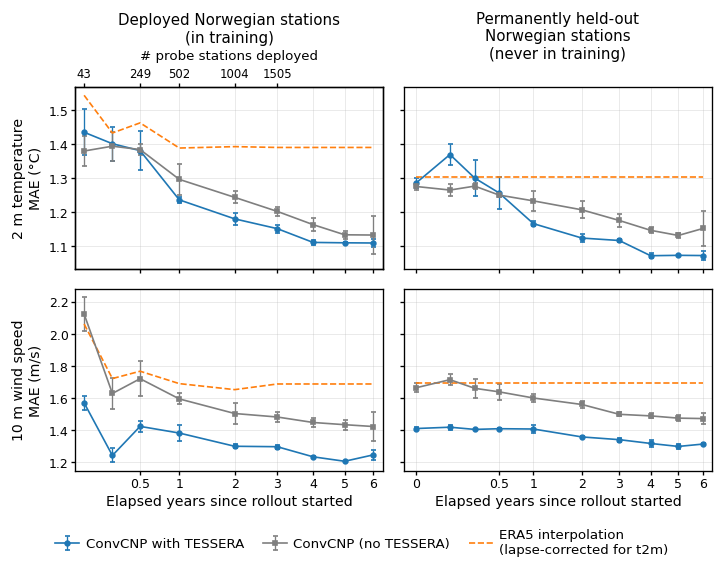

--- probe_undeployed / mae (seed mean +- sd) ---
  t2m
    r0    n= 680  ConvCNP with TESSERA=1.320+-0.018  ConvCNP (no TESSERA)=1.343+-0.024  ERA5=1.390
    r1mo  n= 662  ConvCNP with TESSERA=1.389+-0.032  ConvCNP (no TESSERA)=1.333+-0.022  ERA5=1.386
    r3mo  n= 629  ConvCNP with TESSERA=1.331+-0.052  ConvCNP (no TESSERA)=1.336+-0.011  ERA5=1.387
    r6mo  n= 579  ConvCNP with TESSERA=1.287+-0.043  ConvCNP (no TESSERA)=1.303+-0.012  ERA5=1.377
    r1y   n= 456  ConvCNP with TESSERA=1.219+-0.005  ConvCNP (no TESSERA)=1.291+-0.036  ERA5=1.391
    r2y   n= 230  ConvCNP with TESSERA=1.169+-0.017  ConvCNP (no TESSERA)=1.242+-0.017  ERA5=1.385
  wind
    r0    n= 479  ConvCNP with TESSERA=1.389+-0.014  ConvCNP (no TESSERA)=1.693+-0.048  ERA5=1.687
    r1mo  n= 467  ConvCNP with TESSERA=1.393+-0.016  ConvCNP (no TESSERA)=1.756+-0.066  ERA5=1.678
    r3mo  n= 446  ConvCNP with TESSERA=1.381+-0.014  ConvCNP (no TESSERA)=1.687+-0.077  ERA5=1.685
    r6mo  n= 411  ConvCNP with TESSERA=1.378+-0

In [43]:
# MAE variant of the always-held-out figure — writes the canonical
# (unsuffixed) paper filename. MAE is the paper's headline point metric
# (and the consistent score for the wind median forecasts); the RMSE
# variant above shows the tail-weighted view.
if not df.empty:
    plot_ah_cols('mae')

# Numbers for the prose claim that the held-out pattern carries over to
# the probes that are not yet deployed — the station set the cut middle
# column was about. Reported, not plotted.
if not df.empty:
    report_col('probe_undeployed', 'mae')


In [44]:
# Summary table: same shape as the uniform-horizon notebook so a
# side-by-side comparison is straightforward.
rows = []
for variable in VARIABLES:
    sub_var = df[df['variable'] == variable]
    for family in FAMILIES:
        for sweep_label in SWEEP_ORDER:
            fam_rows = sub_var[
                (sub_var['family'] == family)
                & (sub_var['sweep_label'] == sweep_label)
            ]
            if fam_rows.empty:
                continue
            for subset in SUBSETS:
                mae_col = f'{variable}_{subset}_mae'
                if mae_col not in fam_rows.columns:
                    continue
                vals = fam_rows[mae_col].dropna()
                if vals.empty:
                    continue
                n_st_col = f'{variable}_{subset}_n_stations'
                rows.append({
                    'variable':    variable,
                    'family':      family,
                    'sweep_label': sweep_label,
                    'subset':      subset,
                    'mae_mean':    vals.mean(),
                    'mae_std':     vals.std() if len(vals) > 1 else 0.0,
                    'n_seeds':     len(vals),
                    'n_stations':  int(fam_rows[n_st_col].iloc[0])
                                   if n_st_col in fam_rows.columns
                                      and pd.notna(fam_rows[n_st_col].iloc[0])
                                   else None,
                })
summary = (pd.DataFrame(rows)
             .sort_values(['variable', 'family', 'subset', 'sweep_label']))
if not summary.empty:
    with pd.option_context('display.max_rows', None, 'display.width', 200):
        print(summary.to_string(index=False))


variable   family sweep_label       subset  mae_mean  mae_std  n_seeds  n_stations
     t2m baseline          r0    always_on  1.146762 0.005942        3        4248
     t2m baseline        r1mo    always_on  1.127861 0.010034        3        4248
     t2m baseline         r1y    always_on  1.128539 0.048005        3        4248
     t2m baseline         r2y    always_on  1.128154 0.020359        3        4248
     t2m baseline        r3mo    always_on  1.158233 0.038462        3        4248
     t2m baseline         r3y    always_on  1.125460 0.016990        3        4248
     t2m baseline         r4y    always_on  1.102669 0.030776        3        4248
     t2m baseline         r5y    always_on  1.071602 0.007217        3        4248
     t2m baseline        r6mo    always_on  1.141067 0.008669        3        4248
     t2m baseline         r6y    always_on  1.062774 0.033226        3        4248
     t2m baseline          r0        probe  1.342910 0.023548        3         680
    